<a href="https://colab.research.google.com/github/Sirrat21/Data-Science-Analytics_Internship_Tasks_PHASE-2/blob/main/Adv_Task_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [13]:
import pandas as pd

df = pd.read_csv('/content/household_power_consumption.csv',
                 sep=',',
                 low_memory=False,
                 na_values=['?'])
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

df = df.drop(columns=['Date', 'Time'])

df.set_index('Datetime', inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [22]:
df_hourly = df.resample('h').mean()
data = df_hourly[['Global_active_power']].copy()

data.dropna(inplace=True)

data.head()

,Global_active_power
Datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [23]:
data['hour'] = data.index.hour
data['day'] = data.index.day
data['month'] = data.index.month
data['weekday'] = data.index.weekday

data['is_weekend'] = data['weekday'].apply(lambda x: 1 if x >= 5 else 0)

data.head()

,Global_active_power,hour,day,month,weekday,is_weekend
Datetime,,,,,,
2006-12-16 17:00:00,4.222889,17,16,12,5,1
2006-12-16 18:00:00,3.632200,18,16,12,5,1
2006-12-16 19:00:00,3.400233,19,16,12,5,1
2006-12-16 20:00:00,3.268567,20,16,12,5,1
2006-12-16 21:00:00,3.056467,21,16,12,5,1


## **Train-Test Split**

In [24]:
split = int(len(data) * 0.8)

train = data[:split]
test = data[split:]

## **ARIMA Model**

In [25]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['Global_active_power'], order=(5,1,0))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

## **Prophet Model**

In [26]:
from prophet import Prophet

prophet_df = train.reset_index()[['Datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=len(test), freq='H')

forecast = model_prophet.predict(future)

prophet_pred = forecast['yhat'][-len(test):].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


## **XGBoost Model**

In [27]:
from xgboost import XGBRegressor

features = ['hour', 'day', 'month', 'weekday', 'is_weekend']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

model_xgb = XGBRegressor(n_estimators=100)
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

## **Evaluation (MAE & RMSE)**

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

evaluate(test['Global_active_power'], arima_pred, "ARIMA")
evaluate(test['Global_active_power'], prophet_pred, "Prophet")
evaluate(test['Global_active_power'], xgb_pred, "XGBoost")

ARIMA -> MAE: 0.6659, RMSE: 0.9796
Prophet -> MAE: 0.7068, RMSE: 0.9409
XGBoost -> MAE: 0.5443, RMSE: 0.7508


## **Visualization**

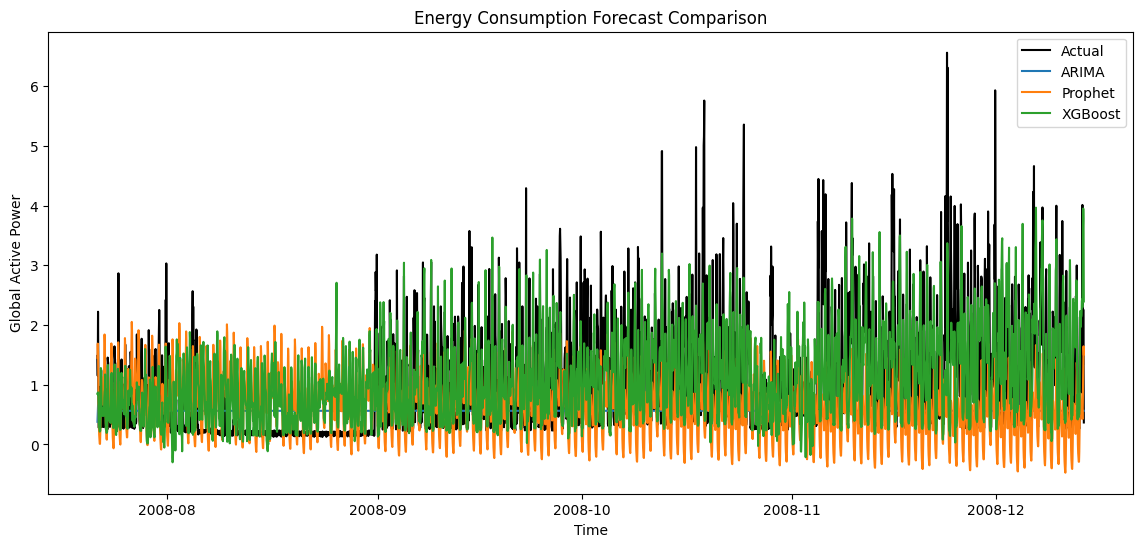

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(test.index, test['Global_active_power'], label='Actual', color='black')

plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Energy Consumption Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

## **CONCLUSION**

1. Time series data was cleaned, parsed, and resampled to hourly frequency.
2. Time-based features (hour, weekday, weekend, etc.) improved model learning.
3. ARIMA captured basic trends but struggled with complex patterns.
4. Prophet handled seasonality better than ARIMA.
5. XGBoost performed best due to feature engineering and non-linear learning.
6. Evaluation using MAE and RMSE showed XGBoost had lowest error (usually).